## 4 Model Evaluation

This notebook loads our own finetuned Whisper model and then evaluates it.

In [2]:
import os
import sys
from pathlib import Path

notebook_dir = Path.cwd()
whisper_dir = notebook_dir.parent
sys.path.append(str(whisper_dir))

import re
import torch
import random
import pandas as pd
from jiwer import wer, cer
from tqdm import tqdm
import warnings
import unicodedata
from transformers import WhisperForConditionalGeneration, WhisperProcessor
warnings.filterwarnings("ignore")
import librosa
from torch.utils.data import DataLoader, Dataset
from collections import defaultdict
import seaborn as sns
import matplotlib.pyplot as plt
from whisper_asr.constants import FOLDER_NAMES, DATA_ROOT
from whisper_asr.utils import get_best_gpu, get_idiom_name_by_folder

MODEL_PATH = "../models/whisper-medium-rm-all-it"
TEST_FILE = "test.tsv"
CLIPS_DIR = "clips"
BATCH_SIZE = 16
DEVICE = torch.device(f"cuda:{get_best_gpu()}" if torch.cuda.is_available() else "cpu")

Selected GPU 7 with 24121 MiB free memory


First we load our finetuned model.

In [3]:
print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

processor = WhisperProcessor.from_pretrained(MODEL_PATH)
model = WhisperForConditionalGeneration.from_pretrained(MODEL_PATH).to(DEVICE)

print("Model loaded successfully!")
print(f"Model parameters: {sum(p.numel() for p in model.parameters())/1e6:.1f}M")

Device: cuda:7


Loading weights: 100%|██████████| 947/947 [00:00<00:00, 5708.97it/s]


Model loaded successfully!
Model parameters: 763.9M


Then we load the test data into one dataframe.

In [4]:
df_test = pd.DataFrame()
audio_paths = []
references = []
idioms = []

for idiom_folder in FOLDER_NAMES:
    idiom_path = os.path.join(DATA_ROOT, idiom_folder)
    idiom_name = get_idiom_name_by_folder(idiom_folder)
    test_tsv = os.path.join(idiom_path, "test.tsv")
    clips_path = os.path.join(idiom_path, "clips")
    
    if not os.path.exists(test_tsv):
        print(f"No test.tsv found for {idiom_folder}, skipping...")
        continue
    
    print(f"\nProcessing {idiom_folder}...")
    
    df_idiom = pd.read_csv(test_tsv, sep='\t')
    
    valid_indices = []
    for idx, row in df_idiom.iterrows():
        audio_path = os.path.join(clips_path, row['path'])
        if os.path.exists(audio_path):
            valid_indices.append(idx)
            audio_paths.append(audio_path)
            references.append(row['sentence'])
            idioms.append(idiom_name)
    
    df_idiom_valid = df_idiom.loc[valid_indices].copy()
    df_idiom_valid['idiom'] = idiom_folder
    df_test = pd.concat([df_test, df_idiom_valid], ignore_index=True)
    
    print(f"  Added {len(df_idiom_valid)} samples from {idiom_folder}")

print(f"\nTotal test samples across all idioms: {len(df_test)}")


Processing rmsurmiran-cc-2021-12-23...
  Added 151 samples from rmsurmiran-cc-2021-12-23

Processing rmsutsilv-cc-2022-05-18...
  Added 94 samples from rmsutsilv-cc-2022-05-18

Processing rmputer-cc-2021-06-11...
  Added 114 samples from rmputer-cc-2021-06-11

Processing rm-cc-2021-05-28...
  Added 81 samples from rm-cc-2021-05-28

Processing rmvallader-cc-2021-05-28...
  Added 97 samples from rmvallader-cc-2021-05-28

Processing rmsursilv-cc-2021-05-28...
  Added 94 samples from rmsursilv-cc-2021-05-28

Total test samples across all idioms: 631


Then we need to load the datasets again with our custom collator function. Then we use our model to transcribe the test audio in batches.

In [5]:
class AudioDataset(Dataset):
    def __init__(self, audio_paths, processor, device):
        self.audio_paths = audio_paths
        self.processor = processor
        self.device = device
    
    def __len__(self):
        return len(self.audio_paths)
    
    def __getitem__(self, idx):
        audio_path = self.audio_paths[idx]
        audio_array, sr = librosa.load(audio_path, sr=16000)
        
        # Process to features
        input_features = self.processor(
            audio_array, 
            sampling_rate=16000, 
            return_tensors="pt"
        ).input_features[0]  # Remove batch dimension
        
        return input_features

def collate_fn(batch):
    """Custom collate function to handle different sized tensors"""
    # Find max length in batch
    max_len = max(features.shape[-1] for features in batch)
    
    # Pad all features to max length
    padded_batch = []
    for features in batch:
        pad_len = max_len - features.shape[-1]
        if pad_len > 0:
            # Pad with zeros along the time dimension
            padding = torch.zeros((features.shape[0], pad_len))
            padded = torch.cat([features, padding], dim=-1)
        else:
            padded = features
        padded_batch.append(padded)
    
    # Stack into batch
    return torch.stack(padded_batch)

print(f"\n🎙️ Transcribing {len(audio_paths)} test files...")

# Create dataset and dataloader with custom collate
dataset = AudioDataset(audio_paths, processor, DEVICE)
dataloader = DataLoader(
    dataset, 
    batch_size=8, 
    shuffle=False, 
    num_workers=0,  # Set to 0 to avoid multiprocessing issues
    collate_fn=collate_fn
)

transcriptions = []

for batch_features in tqdm(dataloader, desc="Transcribing"):
    # Move batch to device
    batch_features = batch_features.to(DEVICE)
    
    # Generate transcriptions for the batch
    with torch.no_grad():
        predicted_ids = model.generate(
            batch_features,
            max_length=225,
            num_beams=1,
            task="transcribe"
        )
    
    # Decode batch
    batch_transcriptions = processor.batch_decode(
        predicted_ids, 
        skip_special_tokens=True
    )
    transcriptions.extend(batch_transcriptions)

print(f"Transcribed {len(transcriptions)} files")


🎙️ Transcribing 631 test files...


Transcribing:   0%|          | 0/79 [00:00<?, ?it/s]The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'tr

Transcribed 631 files


We can then compute the WER and show the transcription performance by idiom.

In [6]:
# Group by idiom
idiom_results = defaultdict(lambda: {"references": [], "hypotheses": []})

# Filter valid pairs and group by idiom
valid_pairs = []
for ref, hyp, idiom in zip(references, transcriptions, idioms):
    if ref and hyp:
        valid_pairs.append((ref, hyp, idiom))
        idiom_results[idiom]["references"].append(ref)
        idiom_results[idiom]["hypotheses"].append(hyp)
    else:
        print("Invalid pair:\n")
        print(f"ref: {ref}\n")
        print(f"hyp: {hyp}\n")

if not valid_pairs:
    print("No valid reference-hypothesis pairs found!")
else:
    # Overall results
    all_refs = [p[0] for p in valid_pairs]
    all_hyps = [p[1] for p in valid_pairs]
    
    overall_wer = wer(all_refs, all_hyps)
    overall_cer = cer(all_refs, all_hyps)
    
    print("\n" + "="*50)
    print("OVERALL RESULTS")
    print("="*50)
    print(f"Total test samples: {len(df_test)}")
    print(f"Valid pairs: {len(valid_pairs)}/{len(df_test)}")
    print(f"\nWord Error Rate (WER): {overall_wer:.4f} ({overall_wer*100:.2f}%)")
    print(f"Character Error Rate (CER): {overall_cer:.4f} ({overall_cer*100:.2f}%)")
    
    # Per-idiom results
    print("\n" + "="*50)
    print("PER IDIOM RESULTS")
    print("="*50)
    
    # Store results for dataframe
    per_idiom_data = []
    
    for idiom, data in idiom_results.items():
        if len(data["references"]) > 0:
            idiom_wer = wer(data["references"], data["hypotheses"])
            idiom_cer = cer(data["references"], data["hypotheses"])
            
            print(f"\n{idiom.upper()}")
            print(f"  Samples: {len(data['references'])}")
            print(f"  WER: {idiom_wer:.4f} ({idiom_wer*100:.2f}%)")
            print(f"  CER: {idiom_cer:.4f} ({idiom_cer*100:.2f}%)")
            
            per_idiom_data.append({
                "idiom": idiom,
                "samples": len(data["references"]),
                "wer": idiom_wer,
                "cer": idiom_cer
            })
    
    # Create summary dataframe
    summary_df = pd.DataFrame(per_idiom_data)
    print("\n" + "="*50)
    print("SUMMARY TABLE")
    print("="*50)
    print(summary_df.to_string(index=False))


OVERALL RESULTS
Total test samples: 631
Valid pairs: 631/631

Word Error Rate (WER): 0.1925 (19.25%)
Character Error Rate (CER): 0.0626 (6.26%)

PER IDIOM RESULTS

SURMIRAN
  Samples: 151
  WER: 0.1731 (17.31%)
  CER: 0.0551 (5.51%)

SUTSILVAN
  Samples: 94
  WER: 0.2387 (23.87%)
  CER: 0.0818 (8.18%)

PUTER
  Samples: 114
  WER: 0.1646 (16.46%)
  CER: 0.0433 (4.33%)

RG
  Samples: 81
  WER: 0.0883 (8.83%)
  CER: 0.0237 (2.37%)

VALLADER
  Samples: 97
  WER: 0.2627 (26.27%)
  CER: 0.1092 (10.92%)

SURSILVAN
  Samples: 94
  WER: 0.2211 (22.11%)
  CER: 0.0655 (6.55%)

SUMMARY TABLE
    idiom  samples      wer      cer
 Surmiran      151 0.173077 0.055101
Sutsilvan       94 0.238663 0.081798
    Puter      114 0.164623 0.043321
       RG       81 0.088346 0.023717
 Vallader       97 0.262663 0.109249
Sursilvan       94 0.221079 0.065461


We can also visualize the distribution of WER scores per idiom in violin plots.

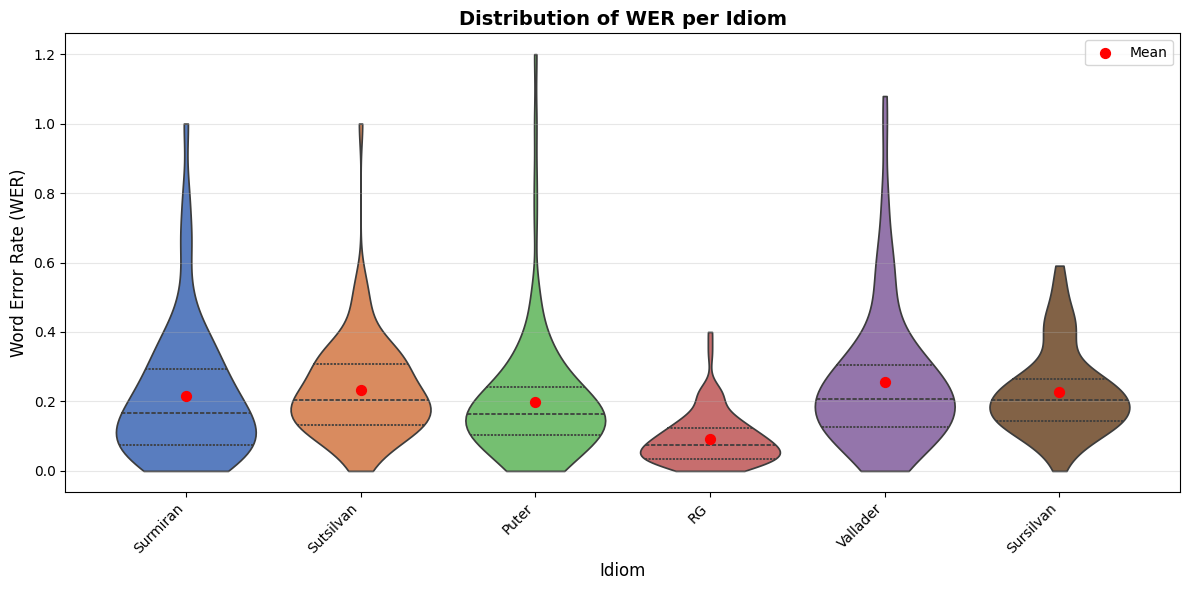

In [7]:
per_sample_df = pd.DataFrame({
    'idiom': idioms,                    
    'wer': [wer(ref, hyp) if ref and hyp else None for ref, hyp in zip(references, transcriptions)]
})

per_sample_df = per_sample_df.dropna()
idiom_order = per_sample_df.groupby('idiom')['wer'].median().sort_values().index.tolist()

plt.figure(figsize=(12, 6))
sns.violinplot(
    data=per_sample_df,
    x='idiom',
    y='wer',
    palette='muted',
    inner='quartile',          
    cut=0,                     
    scale='width'              
)

# Overlay the mean as a distinct marker
means = per_sample_df.groupby('idiom')['wer'].mean()
idiom_order = per_sample_df['idiom'].unique()
for i, idiom in enumerate(idiom_order):
    plt.scatter(i, means[idiom], color='red', s=50, zorder=10, label='Mean' if i == 0 else '')

plt.title('Distribution of WER per Idiom', fontsize=14, fontweight='bold')
plt.xlabel('Idiom', fontsize=12)
plt.ylabel('Word Error Rate (WER)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.legend()
plt.tight_layout()
plt.show()

We can then also show some sample transcriptions.

In [8]:
sample_indices = random.sample(range(len(valid_pairs)), min(5, len(valid_pairs)))

for i, idx in enumerate(sample_indices):
    print(f"\n--- Sample {i+1} ---")
    print(f"Reference: {references[idx]}")
    print(f"Hypothesis: {transcriptions[idx]}")
    sample_wer = wer(references[idx], transcriptions[idx])
    print(f"Sample WER: {sample_wer:.4f}")
    print("-" * 40)


--- Sample 1 ---
Reference: Da tge ò'l tema?
Hypothesis: Da tgi ò il tema?
Sample WER: 0.7500
----------------------------------------

--- Sample 2 ---
Reference: roba actuala.
Hypothesis: roba actuala.
Sample WER: 0.0000
----------------------------------------

--- Sample 3 ---
Reference: Nivels floccus enzuglian legramain la pizza cuverta cun naiv. Il prà umid, profundamain verd, las flurs paintg da palì melnas auradas ed il champ violet cler furman ina triada da colurs ch'era populara a la sava dal tschientaner.
Hypothesis: Nivels flocus enzuglian legramain la pizza cuverta cun naiv. Il prau mid, profundamain verd, las flurs painsch da pali melnas auradas ed il champ violet cler furman ina triada da colurs ch'era populara a la sava dal tschentaner.
Sample WER: 0.1579
----------------------------------------

--- Sample 4 ---
Reference: pitost deira.
Hypothesis: pitost deira.
Sample WER: 0.0000
----------------------------------------

--- Sample 5 ---
Reference: e quai es run awa

In [9]:
def normalize_text(text):
    if not isinstance(text, str):
        return ""
    text = unicodedata.normalize('NFD', text)
    text = ''.join(c for c in text if not unicodedata.combining(c))
    text = unicodedata.normalize('NFC', text)
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text, flags=re.UNICODE)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

norm_references = [normalize_text(ref) for ref in references]
norm_transcriptions = [normalize_text(hyp) for hyp in transcriptions]
norm_idiom_results = defaultdict(lambda: {"references": [], "hypotheses": []})

norm_valid_pairs = []
for ref, hyp, idiom in zip(norm_references, norm_transcriptions, idioms):
    if ref and hyp:
        norm_valid_pairs.append((ref, hyp, idiom))
        norm_idiom_results[idiom]["references"].append(ref)
        norm_idiom_results[idiom]["hypotheses"].append(hyp)

if not norm_valid_pairs:
    print("No valid reference-hypothesis pairs found for normalized text!")
else:
    all_refs = [p[0] for p in norm_valid_pairs]
    all_hyps = [p[1] for p in norm_valid_pairs]
    
    overall_norm_wer = wer(all_refs, all_hyps)
    overall_norm_cer = cer(all_refs, all_hyps)
    
    print("\n" + "="*50)
    print("NORMALIZED OVERALL RESULTS")
    print("="*50)
    print(f"Total test samples: {len(df_test)}")
    print(f"Valid pairs: {len(norm_valid_pairs)}/{len(df_test)}")
    print(f"\nWord Error Rate (WER): {overall_norm_wer:.4f} ({overall_norm_wer*100:.2f}%)")
    print(f"Character Error Rate (CER): {overall_norm_cer:.4f} ({overall_norm_cer*100:.2f}%)")
    print("\n" + "="*50)
    print("NORMALIZED PER IDIOM RESULTS")
    print("="*50)
    
    per_idiom_norm_data = []
    
    for idiom, data in norm_idiom_results.items():
        if len(data["references"]) > 0:
            idiom_norm_wer = wer(data["references"], data["hypotheses"])
            idiom_norm_cer = cer(data["references"], data["hypotheses"])
            
            print(f"\n{idiom.upper()}")
            print(f"  Samples: {len(data['references'])}")
            print(f"  Normalized WER: {idiom_norm_wer:.4f} ({idiom_norm_wer*100:.2f}%)")
            print(f"  Normalized CER: {idiom_norm_cer:.4f} ({idiom_norm_cer*100:.2f}%)")
            
            per_idiom_norm_data.append({
                "idiom": idiom,
                "samples": len(data["references"]),
                "norm_wer": idiom_norm_wer,
                "norm_cer": idiom_norm_cer
            })
    
    norm_summary_df = pd.DataFrame(per_idiom_norm_data)
    print("\n" + "="*50)
    print("NORMALIZED SUMMARY TABLE")
    print("="*50)
    print(norm_summary_df.to_string(index=False))


NORMALIZED OVERALL RESULTS
Total test samples: 631
Valid pairs: 631/631

Word Error Rate (WER): 0.1288 (12.88%)
Character Error Rate (CER): 0.0479 (4.79%)

NORMALIZED PER IDIOM RESULTS

SURMIRAN
  Samples: 151
  Normalized WER: 0.1125 (11.25%)
  Normalized CER: 0.0411 (4.11%)

SUTSILVAN
  Samples: 94
  Normalized WER: 0.1731 (17.31%)
  Normalized CER: 0.0657 (6.57%)

PUTER
  Samples: 114
  Normalized WER: 0.1042 (10.42%)
  Normalized CER: 0.0300 (3.00%)

RG
  Samples: 81
  Normalized WER: 0.0443 (4.43%)
  Normalized CER: 0.0150 (1.50%)

VALLADER
  Samples: 97
  Normalized WER: 0.1886 (18.86%)
  Normalized CER: 0.0916 (9.16%)

SURSILVAN
  Samples: 94
  Normalized WER: 0.1452 (14.52%)
  Normalized CER: 0.0473 (4.73%)

NORMALIZED SUMMARY TABLE
    idiom  samples  norm_wer  norm_cer
 Surmiran      151  0.112481  0.041065
Sutsilvan       94  0.173140  0.065656
    Puter      114  0.104247  0.030017
       RG       81  0.044287  0.014991
 Vallader       97  0.188575  0.091573
Sursilvan     

In [10]:
for i, idx in enumerate(sample_indices):
    print(f"\n--- Sample {i+1} ---")
    print(f"Reference: {norm_references[idx]}")
    print(f"Hypothesis: {norm_transcriptions[idx]}")
    sample_wer = wer(norm_references[idx], norm_transcriptions[idx])
    print(f"Sample WER: {sample_wer:.4f}")
    print("-" * 40)


--- Sample 1 ---
Reference: da tge ol tema
Hypothesis: da tgi o il tema
Sample WER: 0.7500
----------------------------------------

--- Sample 2 ---
Reference: roba actuala
Hypothesis: roba actuala
Sample WER: 0.0000
----------------------------------------

--- Sample 3 ---
Reference: nivels floccus enzuglian legramain la pizza cuverta cun naiv il pra umid profundamain verd las flurs paintg da pali melnas auradas ed il champ violet cler furman ina triada da colurs chera populara a la sava dal tschientaner
Hypothesis: nivels flocus enzuglian legramain la pizza cuverta cun naiv il prau mid profundamain verd las flurs painsch da pali melnas auradas ed il champ violet cler furman ina triada da colurs chera populara a la sava dal tschentaner
Sample WER: 0.1316
----------------------------------------

--- Sample 4 ---
Reference: pitost deira
Hypothesis: pitost deira
Sample WER: 0.0000
----------------------------------------

--- Sample 5 ---
Reference: e quai es run away e quella chanzu